In [1]:
from __future__ import annotations
import operator
from typing import List,Dict,Annotated,TypedDict
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
import os
from pathlib import Path

In [ ]:
model = ChatGroq(
            model="llama-3.3-70b-versatile",
            temperature=0.4,
            api_key=os.getenv("GROQ_API_KEY")
)

In [2]:
class Task(BaseModel):
    id:int
    title:str
    brief:str = Field(...,description="what is cover")

class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]
    
class State(TypedDict):
    topic:str
    plan:Plan
    # reducer: results from workers get concatenated automatically
    sections:Annotated[List[str],operator.add]
    final:str

In [4]:
def orchestrator(state:State)->Dict:
    plan = model.with_structured_output(Plan).invoke({
        [SystemMessage(content="Create a blog plan with 5-7 section on the following topic."),
         HumanMessage(content=f"Topic : {state['topic']}")
        ]
    })
    return {"plan":plan}

In [ ]:
def fanout(state:State):
    # for each task creating the 'Send' object 
    workers_list = [Send("workers",{"task":task,"topic":state['topic'],"plan":state['plan']}) for task in state['plan'].tasks]
    print(workers_list)
    return workers_list


def workers(payload:Dict)->Dict:
    task=payload["task"]
    topic=payload["topic"]
    plan=payload["plan"]
    blog_title=plan.blog_title
    
    section = model.invoke(
        [SystemMessage(content="Write one clean Markdown section."),
        HumanMessage(content=(f"Blog:{blog_title}\n"
                             f"topic:{topic}\n"
                             f"Section:{task.section}\n"
                             f"Brif:{task.brief}\n\n"
                             "Return only the section content in markdown")
                    )
        ]
    ).content.strip()
    return {"section":section}
    

In [8]:
def reducer(state:State)->Dict:
    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip()
    final_markdown = f"# {title}\n\n{body}\n"
    
    # save the file
    filename = title.lower().replace(" ","_")+".md"
    output_path = Path(filename)
    output_path.write_text(final_markdown,encoding="utf-8")
    return {"final":final_markdown}

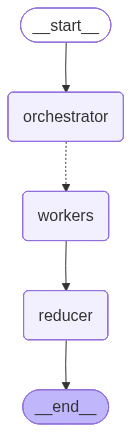

In [11]:
graph = StateGraph(State)

graph.add_node("orchestrator",orchestrator)
graph.add_node("workers",workers)
graph.add_node("reducer",reducer)
# edges
graph.add_edge(START,"orchestrator")
graph.add_conditional_edges("orchestrator",fanout,["workers"])
graph.add_edge("workers","reducer")
graph.add_edge("reducer",END)

app = graph.compile()
app